<a href="https://colab.research.google.com/github/Carla-Brdenk/landing/blob/main/Session_4_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("compustat_NA_data.csv")

In [4]:
print(type(df))
print(df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'>
(58739, 20)


,gvkey,datadate,fyear,indfmt,consol,popsrc,datafmt,tic,conm,curcd,act,at,ceq,dt,lct,ni,revt,exchg,costat,gsector
0,1004,5/31/2018,2017.0,INDL,C,D,STD,AIR,AAR CORP,USD,942.7,1524.7,936.3,177.2,333.3,15.6,1748.3,11.0,A,20.0
1,1004,5/31/2019,2018.0,INDL,C,D,STD,AIR,AAR CORP,USD,952.5,1517.2,905.9,141.7,357.5,7.5,2051.8,11.0,A,20.0
2,1004,5/31/2020,2019.0,INDL,C,D,STD,AIR,AAR CORP,USD,1438.7,2079.0,902.6,684.6,383.1,4.4,2089.3,11.0,A,20.0
3,1004,5/31/2021,2020.0,INDL,C,D,STD,AIR,AAR CORP,USD,937.0,1539.7,974.4,205.1,336.8,35.8,1651.4,11.0,A,20.0
4,1004,5/31/2022,2021.0,INDL,C,D,STD,AIR,AAR CORP,USD,1007.2,1573.9,1034.5,167.4,348.2,78.7,1817.1,11.0,A,20.0


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("compustat_NA_data.csv")

print("Type of df:", type(df))
print("Initial shape:", df.shape)

duplicate_count = df.duplicated(subset=['fyear', 'conm']).sum()
print("Number of duplicates:", duplicate_count)

df = df.drop_duplicates(subset=['fyear', 'conm'], keep='first')

df = df[(df['revt'] > 0) & (df['at'] > 0) & (df['dt'] > 0)].copy()

print("Shape after cleaning:", df.shape)

Type of df: <class 'pandas.core.frame.DataFrame'>
Initial shape: (58739, 20)
Number of duplicates: 4209
Shape after cleaning: (23916, 20)


In [6]:
df_subset = df[['fyear', 'conm', 'tic', 'gsector', 'act', 'lct', 'ni', 'at', 'revt', 'dt', 'ceq']].copy()

df_subset['Current_Ratio'] = df_subset['act'] / df_subset['lct']
df_subset['ROA'] = df_subset['ni'] / df_subset['at']
df_subset['Asset_Turnover'] = df_subset['revt'] / df_subset['at']
df_subset['Debt_to_Equity'] = df_subset['dt'] / df_subset['ceq']

financial_columns = ['Current_Ratio', 'ROA', 'Asset_Turnover', 'Debt_to_Equity']

df_subset.head()

,fyear,conm,tic,gsector,act,lct,ni,at,revt,dt,ceq,Current_Ratio,ROA,Asset_Turnover,Debt_to_Equity
0,2017.0,AAR CORP,AIR,20.0,942.7,333.3,15.6,1524.7,1748.3,177.2,936.3,2.828383,0.010232,1.146652,0.189256
1,2018.0,AAR CORP,AIR,20.0,952.5,357.5,7.5,1517.2,2051.8,141.7,905.9,2.664336,0.004943,1.352360,0.156419
2,2019.0,AAR CORP,AIR,20.0,1438.7,383.1,4.4,2079.0,2089.3,684.6,902.6,3.755416,0.002116,1.004954,0.758476
3,2020.0,AAR CORP,AIR,20.0,937.0,336.8,35.8,1539.7,1651.4,205.1,974.4,2.782067,0.023251,1.072547,0.210489
4,2021.0,AAR CORP,AIR,20.0,1007.2,348.2,78.7,1573.9,1817.1,167.4,1034.5,2.892590,0.050003,1.154521,0.161817


In [7]:
df_subset.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Missing values before treatment:")
print(df_subset[financial_columns].isna().sum())

for col in financial_columns:
    valid_values = df_subset[col][np.isfinite(df_subset[col])].dropna()

    lower_bound = np.quantile(valid_values, 0.05)
    upper_bound = np.quantile(valid_values, 0.95)

    df_subset[col] = np.clip(df_subset[col], lower_bound, upper_bound)

    clipped_median = df_subset[col][
        (df_subset[col] >= lower_bound) & (df_subset[col] <= upper_bound)
    ].median()

    df_subset[col] = df_subset[col].fillna(clipped_median)

print("Missing values after treatment:")
print(df_subset[financial_columns].isna().sum())

Missing values before treatment:
Current_Ratio     2690
ROA                  1
Asset_Turnover       0
Debt_to_Equity      55
dtype: int64
Missing values after treatment:
Current_Ratio     0
ROA               0
Asset_Turnover    0
Debt_to_Equity    0
dtype: int64


In [8]:
selected_company = "AAR CORP"

company_data = df_subset[df_subset['conm'] == selected_company].copy()

if company_data.empty:
    print("Company not found. Here are some examples:")
    print(df_subset['conm'].drop_duplicates().sort_values().head(20))
else:
    sector = company_data['gsector'].iloc[0]
    print("Sector:", sector)

    sector_peers = df_subset[df_subset['gsector'] == sector].copy()

    peer_company_medians = (
        sector_peers
        .groupby(['conm', 'tic', 'gsector'])[financial_columns]
        .median()
        .reset_index()
    )

    company_median = company_data[financial_columns].median()
    industry_median = sector_peers[financial_columns].median()

    comparison_df = pd.DataFrame({
        'Selected Company': company_median,
        'Industry Median': industry_median
    })

    print(comparison_df)

Sector: 20.0
                Selected Company  Industry Median
Current_Ratio           2.892590         1.689075
ROA                     0.016715         0.031945
Asset_Turnover          1.085920         0.829947
Debt_to_Equity          0.210489         0.511976


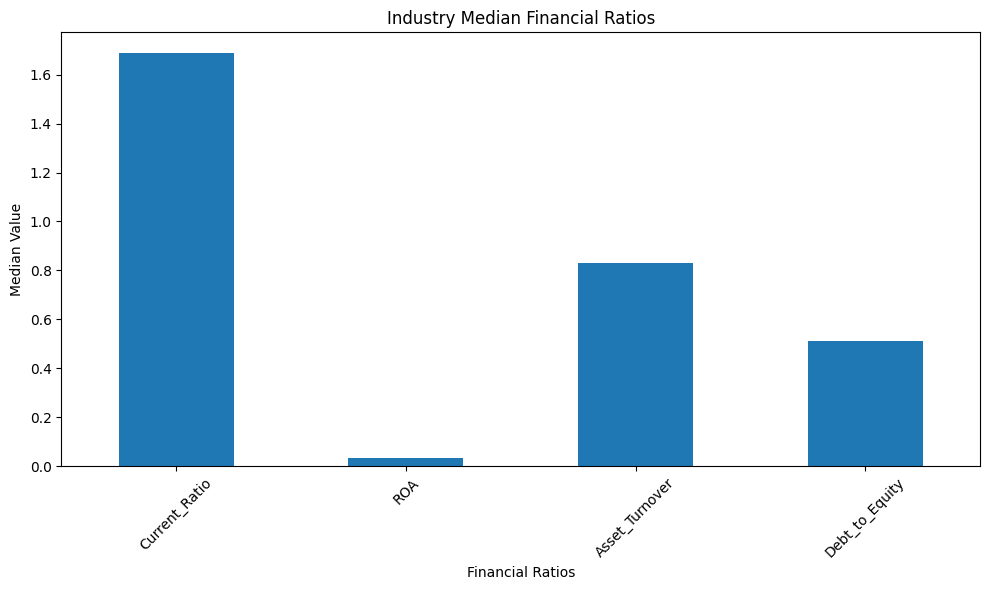

In [9]:
plt.figure(figsize=(10, 6))
industry_median.plot(kind='bar')
plt.title("Industry Median Financial Ratios")
plt.xlabel("Financial Ratios")
plt.ylabel("Median Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

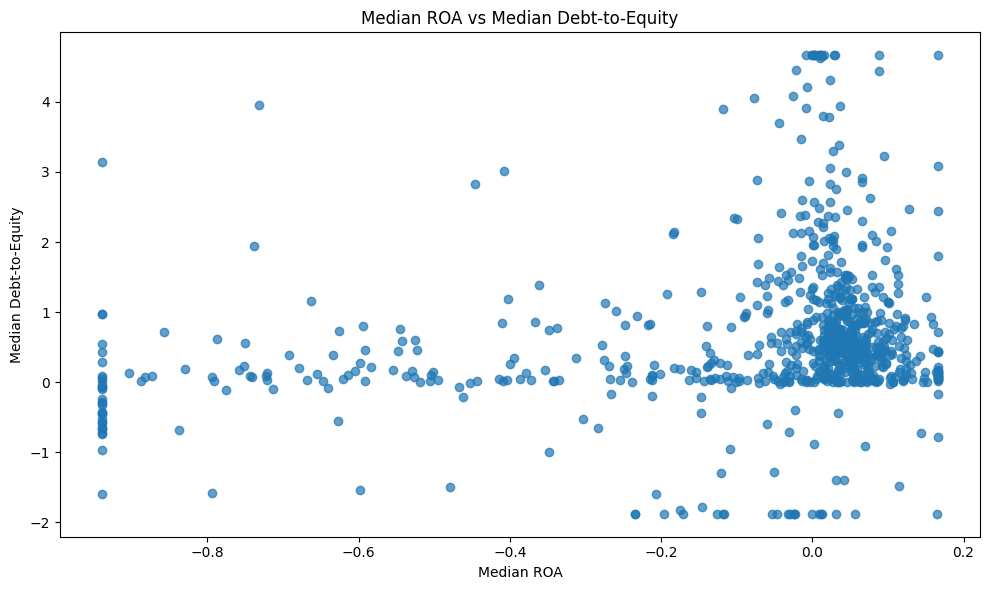

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(peer_company_medians['ROA'], peer_company_medians['Debt_to_Equity'], alpha=0.7)
plt.title("Median ROA vs Median Debt-to-Equity")
plt.xlabel("Median ROA")
plt.ylabel("Median Debt-to-Equity")
plt.tight_layout()
plt.show()

/tmp/ipykernel_365/4273760630.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_subset[col] for col in financial_columns], labels=financial_columns)


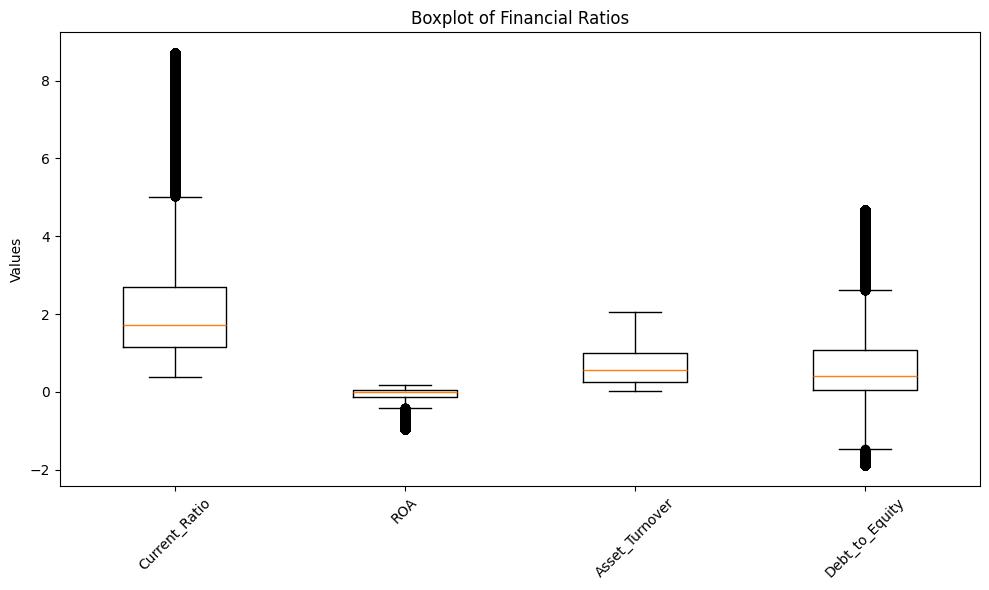

In [11]:
plt.figure(figsize=(10, 6))
plt.boxplot([df_subset[col] for col in financial_columns], labels=financial_columns)
plt.title("Boxplot of Financial Ratios")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
!pip install XlsxWriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.3 MB/s eta 0:00:00


In [13]:
excel_filename = "financial_report.xlsx"

with pd.ExcelWriter(excel_filename, engine='xlsxwriter') as writer:
    comparison_df.to_excel(writer, sheet_name='Median Comparison')
    peer_company_medians.to_excel(writer, sheet_name='Peer Comparison', index=False)
    industry_median.to_frame(name='Median').to_excel(writer, sheet_name='Industry Median')

print("Excel file created:", excel_filename)

Excel file created: financial_report.xlsx


In [15]:
from google.colab import files
files.download(excel_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>